## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=42, experiments_root="/home/data/saeid/experiments")
df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


,end_to_end_s
count,18213.000000
mean,71.302542
std,132.079527
min,0.038300
50%,23.745030
90%,185.419368
99%,742.302252
max,1196.604320


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,ttft_s,tpot_avg_s,streaming,endpoint_id
0,0,bed0842b35d94d38b7c3a25afbb49e24,False,14.58906,14.58906,tool_calls,132670,75,None,3.98497,0.14330,True,vllm-minimax-m2-0
1,1,406169dd77884f0abab9ae49de21c1c8,False,79.07232,79.07232,stop,43865,407,None,1.17212,0.19187,True,vllm-minimax-m2-0
2,2,afbef6ad21fb4f869df0d34b7851de31,False,5.93291,5.93291,tool_calls,98035,62,None,1.58335,0.07130,True,vllm-minimax-m2-1
3,3,fca5cb0ee3d24bf8946a65e5931651e5,False,116.56533,116.56533,stop,157169,560,None,16.40222,0.17918,True,vllm-minimax-m2-0
4,4,999e2ea8d5d947878335728f4312c391,False,418.61858,418.61858,tool_calls,79092,3282,None,11.45028,0.12410,NaN,vllm-minimax-m2-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18208,18208,a333768e218245dba0e04571f1576667,False,29.42372,29.42372,stop,282,476,None,0.65291,0.06057,True,vllm-minimax-m2-0
18209,18209,24db04f54be44960bb015d187824472f,False,74.69509,74.69509,stop,355,1241,None,0.62724,0.05973,True,vllm-minimax-m2-0
18210,18210,593988eaf8c147bdacb153f45300de1b,False,112.77551,112.77551,stop,96484,1007,None,10.91254,0.10126,True,vllm-minimax-m2-0
18211,18211,2f62e80e24cb4231af969207eeed853a,False,6.74438,6.74438,tool_calls,100811,87,None,1.47126,0.06132,True,vllm-minimax-m2-0


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[83]


[83]

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 83:
  client_to_router_s          :      nan s
  router_queue_s              :      nan s
  router_to_sidecar_s         :      nan s
  sidecar_queue_s             :      nan s
  vllm_compute_s              :      nan s
  sidecar_post_s              :      nan s
  sidecar_to_router_s         :      nan s
  router_post_result_s        :      nan s
  SUM (components)            :    0.000 s

  Router post-result breakdown:
    router_result_handler_s   :      nan s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000000 s

  end_to_end_s                :   66.382 s



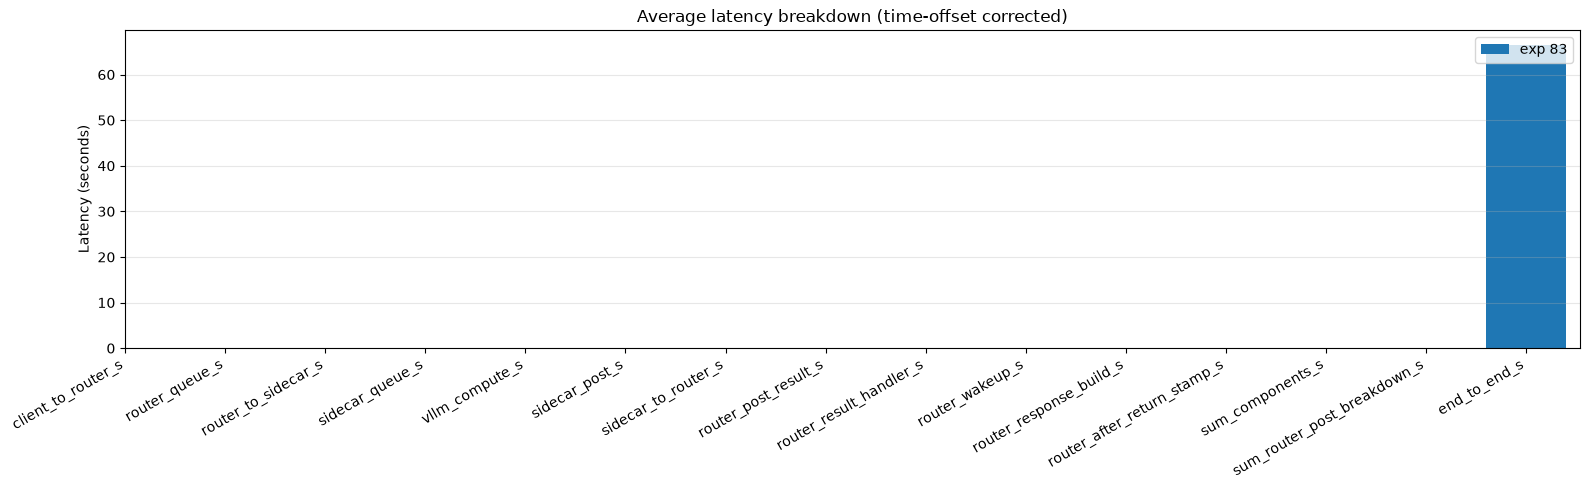

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
        experiments_root="/home/data/saeid/experiments"
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    df = df.iloc[20:]
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[83]


,exp83_end_to_end_s,exp83_ttft_s
count,3377.000000,3377.000000
mean,66.560951,3.113014
std,114.900796,3.801470
min,0.915370,0.600830
50%,28.564220,1.946800
90%,151.107028,5.592852
99%,659.628307,20.594392
max,1105.822430,31.739170


In [7]:
# from experiment_analysis import load_experiment_latencies
# import pandas as pd
# # ---- choose experiments (exclude first 20 entries) ----
# # choose which series you want
# # series_ids = [35]
# # experiments = experiments_from_series(series_ids)
# experiments = [83]
# print(experiments)
# # ----------------------------------------------
# # Latency columns of interest
# cols = [
#     "end_to_end_s",
#     # "server_roundtrip_s",
#     # "router_queue_s",
#     # "vllm_compute_s",
# ]
# percentiles = [0.5, 0.9, 0.99]
# summaries = []
# for exp_id in experiments:
#     df = load_experiment_latencies(exp_id=exp_id)
#     df = df.iloc[20:]
#     summary = (
#         df.describe(percentiles=percentiles)[cols]
#           .add_prefix(f"exp{exp_id}_")
#     )
#     summaries.append(summary)
# # Combine all experiments side-by-side
# comparison = pd.concat(summaries, axis=1)
# comparison


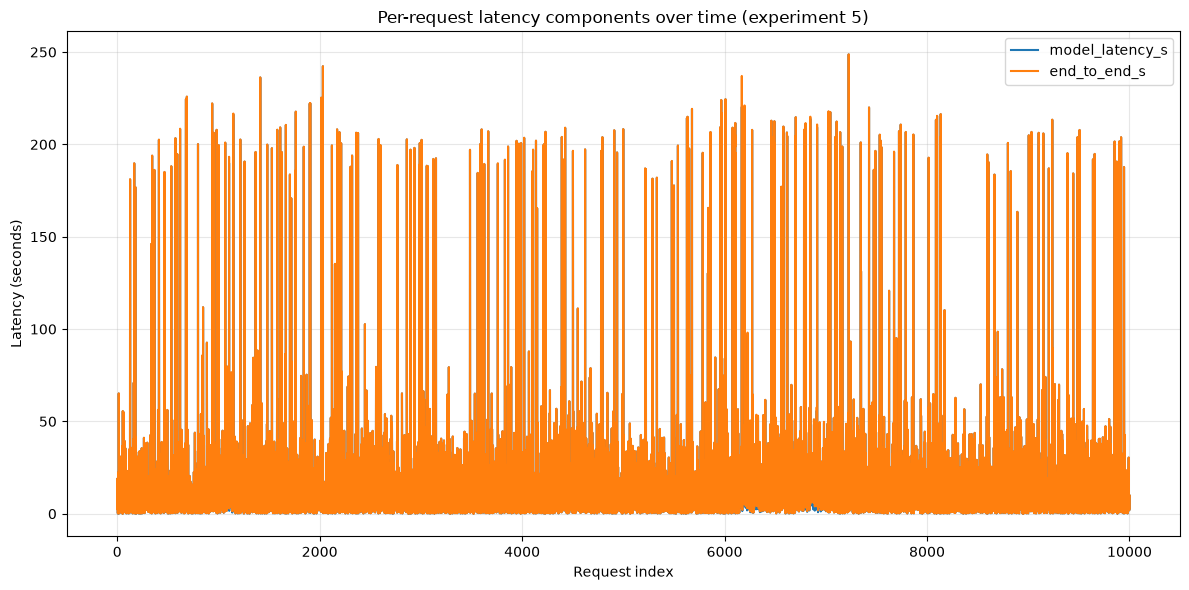

In [8]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 5
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(
    exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments").sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[83]


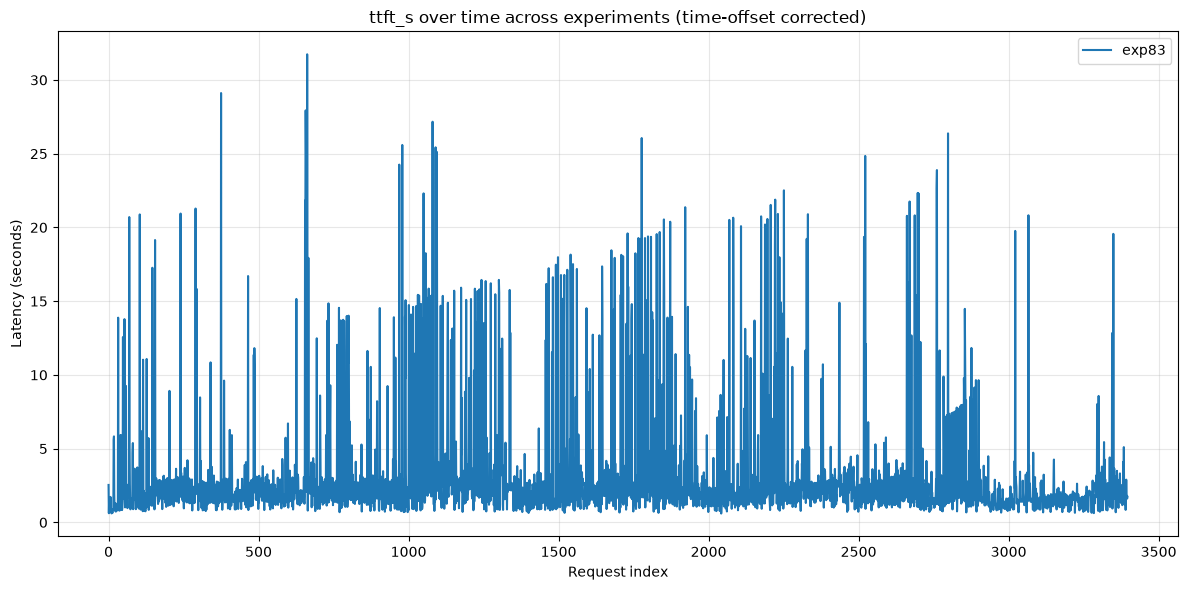

In [9]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


[83]
Saved figure to /home/saeid/llm-lb/analysis-notebooks/figs/ttft_s_exp83_corrected.png


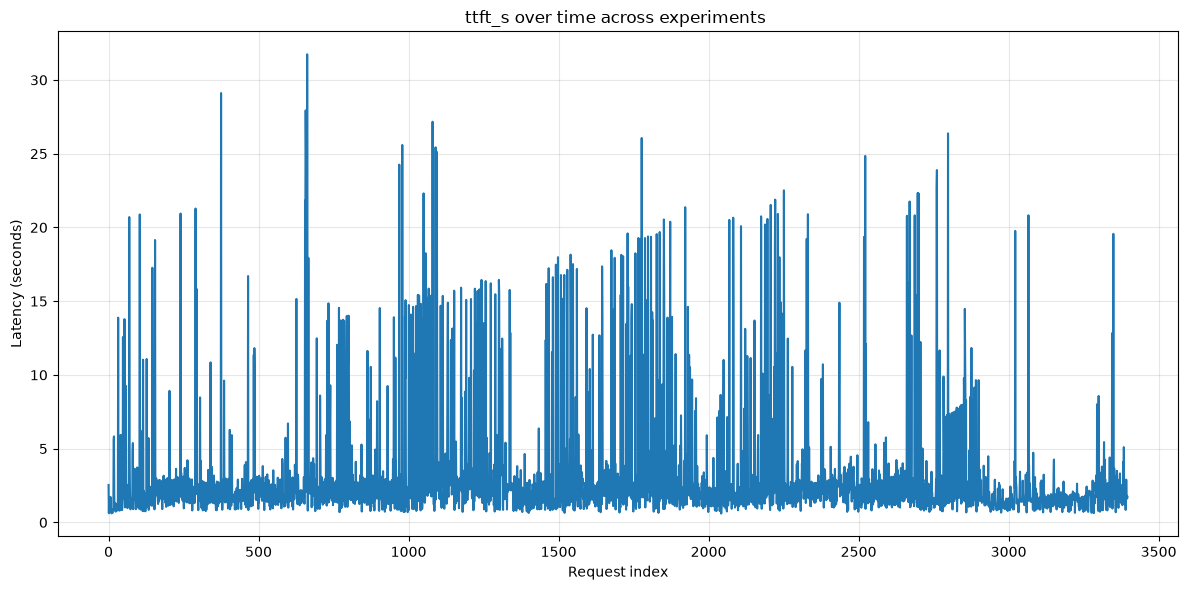

In [10]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]
print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]
    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
)
# plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# ---- save figure ----
save_dir = "/home/saeid/llm-lb/analysis-notebooks/figs"
os.makedirs(save_dir, exist_ok=True)
exp_tag = "_".join(str(e) for e in experiments)
suffix = "corrected" if APPLY_TIME_OFFSETS else "raw"
save_path = os.path.join(save_dir, f"{metric}_exp{exp_tag}_{suffix}.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {save_path}")
# ---------------------

plt.show()

## Throughput Metrics

In [11]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "preemptions_per_sec",
    # --- prefix cache rates (sum across instances) ---
    # "prefix_cache_hits_per_sec",
    # "prefix_cache_queries_per_sec",
    # "ext_prefix_cache_hits_per_sec",
    # "ext_prefix_cache_queries_per_sec",
    # "prompt_tokens_cached_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
    # "kv_cache_usage_perc",           # GPU KV cache usage (%)
    # "prefix_cache_hit_rate",         # derived: hits / queries
    # "ext_prefix_cache_hit_rate",     # derived: ext hits / ext queries
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[83]
[WARN] exp83: columns not found in prom, skipping: {'tpot_seconds_avg'}


,exp83_gen_tokens_per_sec,exp83_ttft_seconds_avg,exp83_tpot_seconds_avg
count,1090.000000,871.000000,NaN
mean,187.076628,2.063571,NaN
std,78.351617,2.150085,NaN
min,30.680000,0.369492,NaN
50%,173.100690,1.196202,NaN
90%,292.206695,4.852862,NaN
99%,376.920138,9.794183,NaN
max,410.064828,20.972519,NaN
SLO_COMPLIANCE_%,NaN,6.773823,NaN


[78]


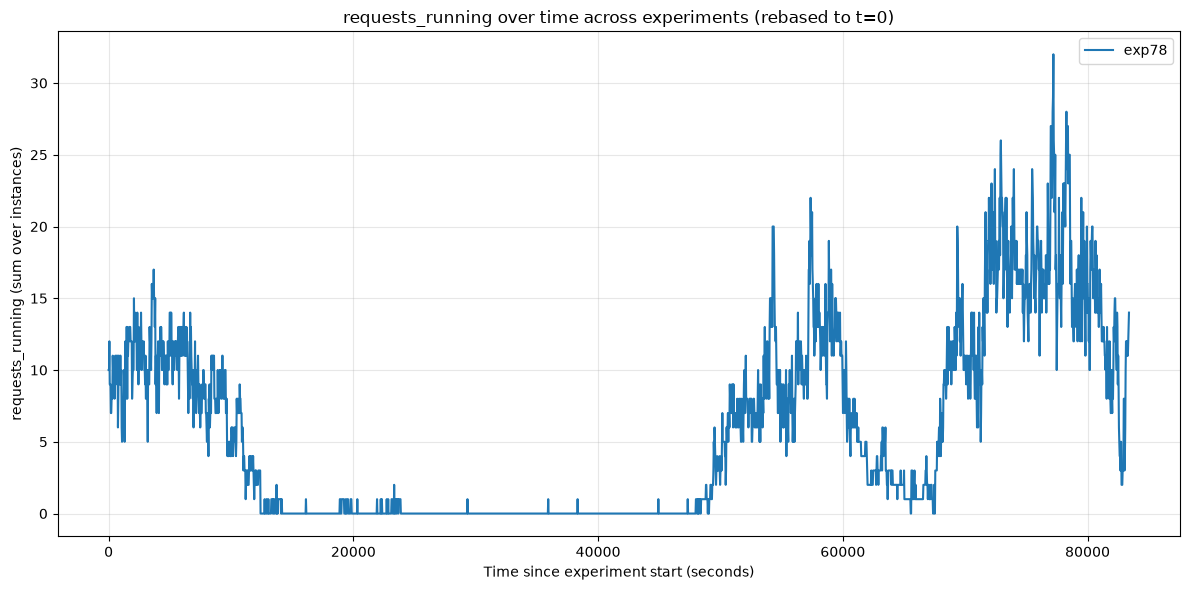

In [12]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [78]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[83]


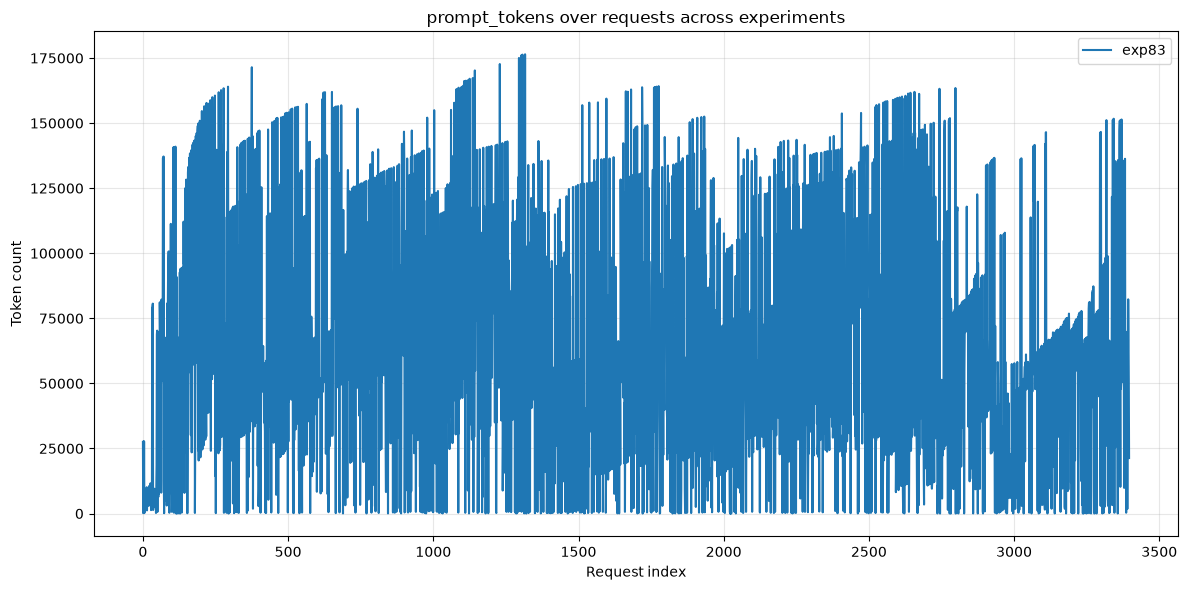

In [13]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
# metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            experiments_root="/home/data/saeid/experiments")
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [14]:
from experiment_analysis import load_experiment_latencies

experiments = [83]

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

exp83: 0 total tokens


[83]


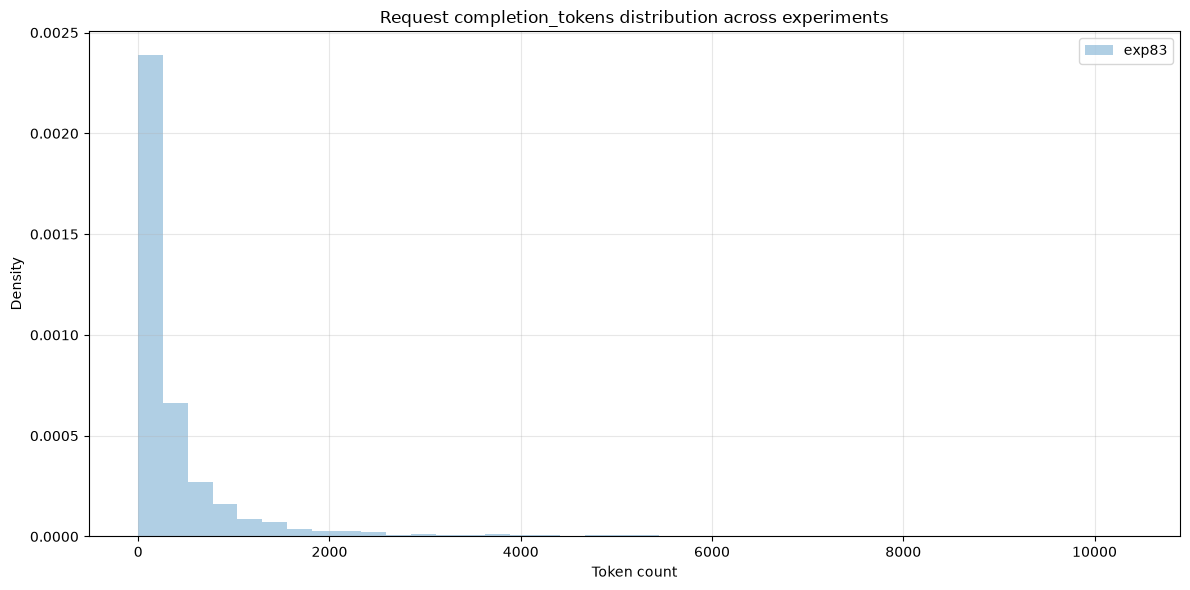

In [15]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
metric = "completion_tokens"  # output length distribution
# metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [16]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/home/data/saeid/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[83]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,83,3397,3397,0,100.0,0.0


In [17]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
    # "sidecar_workers_total",
    # "sidecar_workers_busy",
    # "sidecar_python_threads",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[83]
[WARN] exp83: no vLLM (:8200) samples found for sidecar_*


,exp83_router_queue_length,exp83_router_admission_rps,exp83_router_outgoing_rps
count,1089.000000,1089.000000,1089.000000
mean,0.002755,0.106281,0.062596
std,0.052438,0.126367,0.076781
min,0.000000,0.000000,0.000000
50%,0.000000,0.068357,0.034483
90%,0.000000,0.310345,0.172414
99%,0.000000,0.448276,0.275862
max,1.000000,0.562963,0.422193


[83]


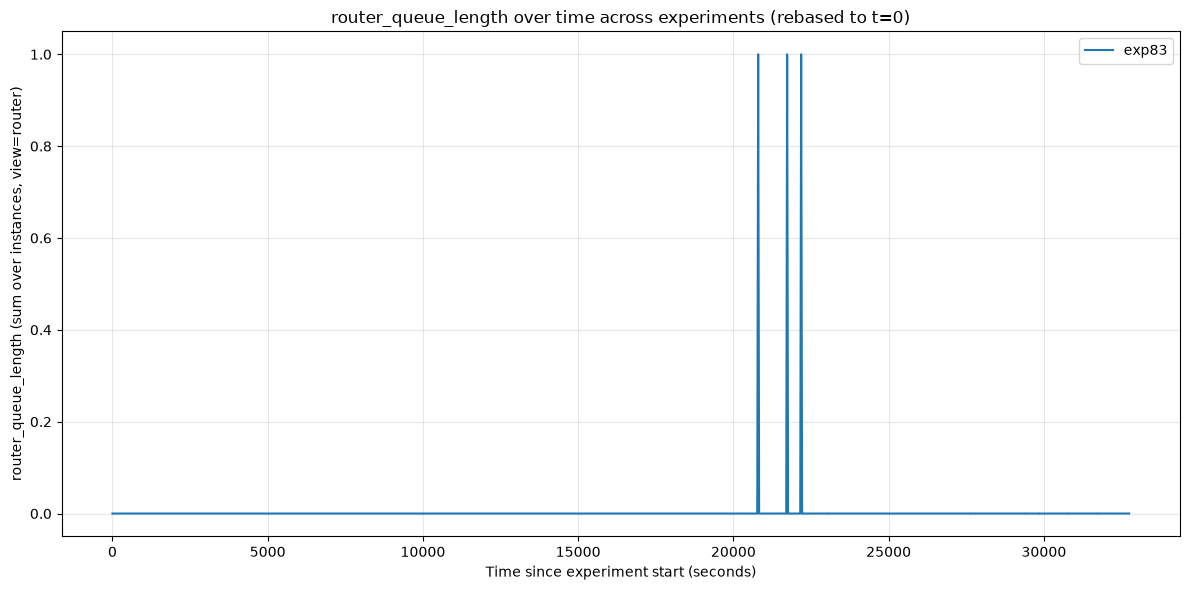

In [18]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"
# metric = "sidecar_workers_total"
# metric = "sidecar_workers_busy"
# metric = "sidecar_python_threads"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[83]


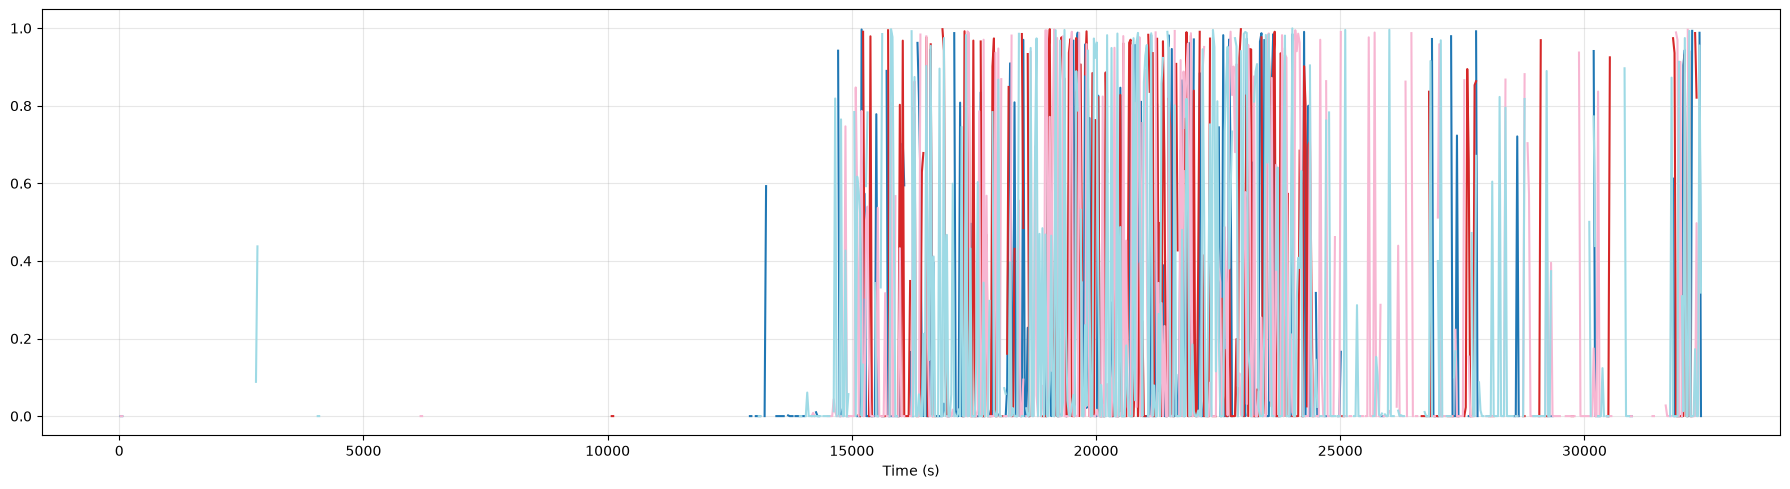

In [19]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    """Extract port from instance strings like '1.2.3.4:8200' or '1.2.3.4:8200:0' (DP engine suffix)."""
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = plt.colormaps["tab20"].resampled(len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()


In [20]:
# ============================================================
# Reproduce the dashboard's "Backend Model TPS" ranking
# (verified to match the web page exactly)
#
# Algorithm = the page's updateTPSRanking:
#   seconds   = ts[-1] - ts[-2]
#   outputTps = (output_tokens[-1] - output_tokens[-2]) / seconds
#   totalTps  = ((out[-1]+in[-1]) - (out[-2]+in[-2])) / seconds
#   cache     = prefix_cache_hits_percent[-1]
#
# Data source: live API or a stored snapshot (toggle below)
# ============================================================
import json, glob, os, datetime as dt

# ---------- config ----------
USE_LIVE = False   # True = hit the live API to reproduce the current ranking
                  # False = compute from the latest stored snapshot
LIVE_URL = "http://10.44.142.113:9999/zhongruan_api/api/data/1hour"
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"  # used when USE_LIVE=False
# ----------------------------

def parse_ts(s):
    """Parse a timestamp string from the API into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def load_data():
    """Load the data JSON either from the live API or the newest snapshot."""
    if USE_LIVE:
        import urllib.request
        with urllib.request.urlopen(LIVE_URL, timeout=20) as r:
            return json.load(r)
    else:
        f = sorted(glob.glob(SNAP_GLOB))[-1]   # newest snapshot
        print(f"Reading snapshot: {os.path.basename(f)}")
        return json.load(open(f, encoding="utf-8"))

def fmt_tps(v):
    """Replicate the page's formatTPS: >=1e6 -> M, >=1e3 -> K, else raw."""
    if v >= 1e6: return f"{v/1e6:.1f}M token/s"
    if v >= 1e3: return f"{v/1e3:.1f}K token/s"
    return f"{v:.1f} token/s"

def backend_tps_ranking(data):
    """Compute the backend-model TPS ranking exactly as the dashboard does."""
    timestamps = data.get("timestamps") or []
    idm = data.get("identifier_metrics") or {}
    if len(timestamps) < 2:
        print("Fewer than 2 time points; cannot compute."); return []

    # Time delta between the last two datapoints (in seconds)
    last_ts, prev_ts = parse_ts(timestamps[-1]), parse_ts(timestamps[-2])
    seconds = (last_ts - prev_ts).total_seconds()
    if seconds <= 0:
        print("Non-positive time delta."); return []

    items = []
    for ident, m in idm.items():
        if "gateway" in ident.lower():          # the page filters out gateway
            continue
        out = m.get("output_tokens") or []
        inp = m.get("input_tokens") or []
        if len(out) < 2:
            continue
        # Pure output TPS: delta of cumulative output tokens / time delta
        last_out, prev_out = out[-1] or 0, out[-2] or 0
        out_diff = last_out - prev_out
        if out_diff <= 0:                        # page rule: no output -> not ranked
            continue
        # Total TPS: delta of (output + input) tokens / time delta
        last_in  = (inp[-1] if len(inp) >= 1 else 0) or 0
        prev_in  = (inp[-2] if len(inp) >= 2 else 0) or 0
        total_diff = (last_out + last_in) - (prev_out + prev_in)

        # Cache hit rate: latest value of the prefix cache hit percentage
        cache_arr = m.get("prefix_cache_hits_percent") or []
        cache = cache_arr[-1] if cache_arr else None

        items.append({
            "name": ident,
            "output_tps": out_diff / seconds,
            "total_tps": total_diff / seconds if total_diff > 0 else 0.0,
            "cache": cache,
        })
    items.sort(key=lambda x: x["output_tps"], reverse=True)   # sort by output TPS desc
    return items, last_ts, prev_ts, seconds

# ---------- run ----------
data = load_data()
result = backend_tps_ranking(data)
if result:
    items, last_ts, prev_ts, seconds = result
    print(f"Time window: {prev_ts:%Y-%m-%d %H:%M} -> {last_ts:%H:%M}  ({seconds:.0f}s)\n")
    print(f"{'#':>2} {'model':<32} {'output token/s':>14} | {'total token/s':>14} | cache")
    print("-" * 80)
    for i, it in enumerate(items, 1):
        cache_str = f"{it['cache']:.1f}%" if it["cache"] is not None else "—"
        print(f"{i:>2} {it['name']:<32} {fmt_tps(it['output_tps']):>14} | "
              f"{fmt_tps(it['total_tps']):>14} | {cache_str}")

Reading snapshot: 20260709_140117_zhongruan_api_api_data_24hour.json
Time window: 2026-07-09 13:50 -> 14:00  (600s)

 # model                            output token/s |  total token/s | cache
--------------------------------------------------------------------------------
 1 GLM-5.1-direct100                 662.3 token/s |  46.8K token/s | 4.4%
 2 MiniMax-M2.7-direct202            152.9 token/s |   5.0K token/s | 54.8%
 3 MiniMax-M2.7-llmla2-direct65       85.1 token/s |  132.1 token/s | 79.7%
 4 MiniMax-M2.7-llmla1-direct65       63.7 token/s |  877.0 token/s | 75.1%
 5 Qwen3.5-direct225                  55.1 token/s |  164.5 token/s | 81.2%
 6 MiniMax-M2.7-direct142             18.6 token/s |   49.4 token/s | 67.6%
 7 Qwen3.5-direct155                   6.0 token/s |  477.1 token/s | 79.0%


In [21]:
# ============================================================
# Cell 0 — shared loader + series builders (run this first)
# TPS  : web algorithm = (output_tokens[i]-output_tokens[i-1]) / (ts[i]-ts[i-1])
# cache: total prefix cache hit rate = total_cache_hits_percent[i] (latest per point)
# All later cells reuse these helpers.
# ============================================================
import json, glob, os, datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- config ----------
SNAP_GLOB = "/home/data/saeid/experiments_hq/1/*api_data_*.json"
GAP_SECONDS = 20 * 60   # break the line if two points are more than this apart
# ----------------------------

def parse_ts(s):
    """Parse an API timestamp string into a datetime."""
    for fmt in ("%Y-%m-%dT%H:%M", "%Y-%m-%dT%H:%M:%S", "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except (ValueError, TypeError): continue
    return None

def parse_window(s):
    """Parse a user-given time bound like '2026-06-24 17:30'."""
    if s is None: return None
    for fmt in ("%Y-%m-%d %H:%M", "%Y-%m-%dT%H:%M", "%Y-%m-%d %H:%M:%S"):
        try: return dt.datetime.strptime(s, fmt)
        except ValueError: continue
    raise ValueError(f"Bad time: {s} (use e.g. '2026-06-24 17:30')")

def load_snapshots():
    """Yield (filepath, parsed_json) for every data snapshot."""
    for fp in sorted(glob.glob(SNAP_GLOB)):
        try:
            yield fp, json.load(open(fp, encoding="utf-8"))
        except Exception as e:
            print(f"[skip] {fp}: {e}")

def build_tps(models):
    """Return {model: {datetime: output_tps}} using the verified web algorithm."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            out = v.get("output_tokens") or []
            n = min(len(out), len(ts_dt))
            for i in range(1, n):
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                cur, prev = out[i], out[i-1]
                if cur is None or prev is None: continue
                secs = (ts_dt[i] - ts_dt[i-1]).total_seconds()
                if secs <= 0: continue
                tps = (cur - prev) / secs
                if tps <= 0: continue           # drop zero/negative (no output / restart)
                series[m][ts_dt[i]] = round(tps, 2)
    return series

def build_cache(models):
    """Return {model: {datetime: total_cache_hit_pct}} (total prefix cache hit rate)."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            cache = v.get("total_cache_hits_percent") or []   # total = (prefix+external)/queries
            n = min(len(cache), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or cache[i] is None: continue
                series[m][ts_dt[i]] = round(cache[i], 2)
    return series

def filter_window(series, start, end):
    """Keep only points within [start, end] (either bound may be None)."""
    if start is None and end is None:
        return series
    return {m: {t: v for t, v in pts.items()
                if (start is None or t >= start) and (end is None or t <= end)}
            for m, pts in series.items()}

def split_gaps(xs, ys, gap):
    """Split a series into segments wherever there is a time gap (avoid drawing over blanks)."""
    segs, cx, cy = [], [], []
    for i, x in enumerate(xs):
        if cx and (x - cx[-1]).total_seconds() > gap:
            segs.append((cx, cy)); cx, cy = [], []
        cx.append(x); cy.append(ys[i])
    if cx: segs.append((cx, cy))
    return segs

# Models to plot (edit as needed)
MODELS = [
    "MiniMax-M2.7-llmla1-direct65",
    "MiniMax-M2.7-llmla2-direct65",
    "MiniMax-M2.7-direct142",
    # "MiniMax-M2.7-direct202",
]
print("Helpers ready. Snapshots found:", len(list(glob.glob(SNAP_GLOB))))

Helpers ready. Snapshots found: 4541


[ok] MiniMax-M2.7-llmla1-direct65: 1920 points
[ok] MiniMax-M2.7-llmla2-direct65: 1833 points
[ok] MiniMax-M2.7-direct142: 2021 points


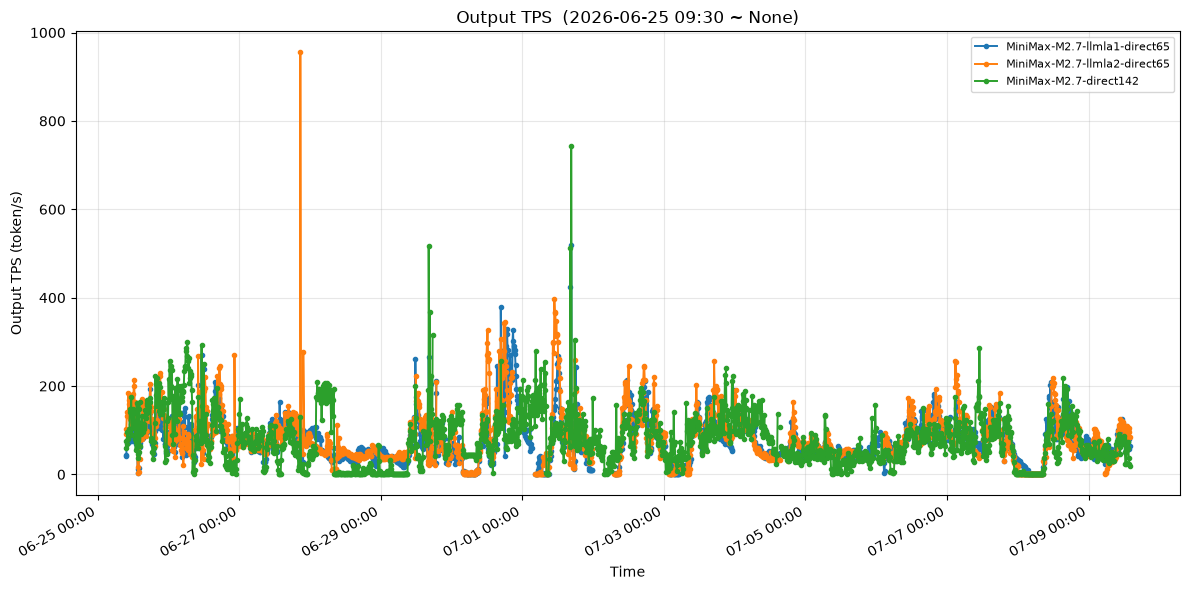

In [22]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-06-25 09:30"    # set to None for no lower bound
END   = None #"2026-06-25 16:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in tps.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):   # break across gaps
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Output TPS (token/s)")
plt.title(f"Output TPS  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean output TPS = 77.3  (n=1776)
[ok] MiniMax-M2.7-llmla2-direct65: mean output TPS = 82.5  (n=1689)
[ok] MiniMax-M2.7-direct142: mean output TPS = 74.5  (n=1877)


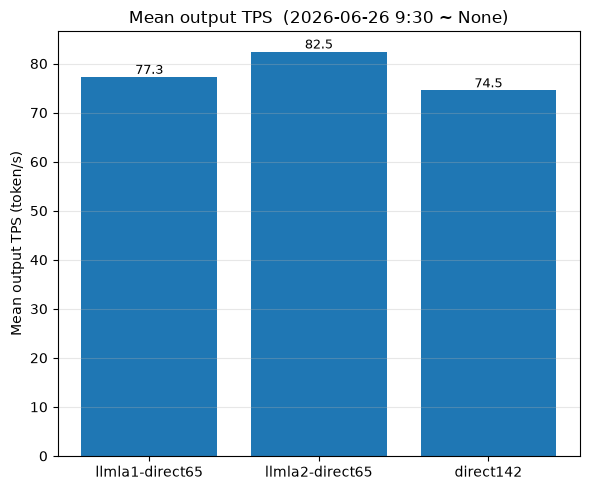

In [23]:
# ============================================================
# Cell 2 — TPS bar chart: mean output TPS per model over the window
# ============================================================
START = "2026-06-26 9:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean output TPS = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean output TPS (token/s)")
plt.title(f"Mean output TPS  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65 -> llm-la-1: 494 points
[ok] MiniMax-M2.7-llmla2-direct65 -> llm-la-2: 494 points
[ok] MiniMax-M2.7-direct142 -> original: 502 points


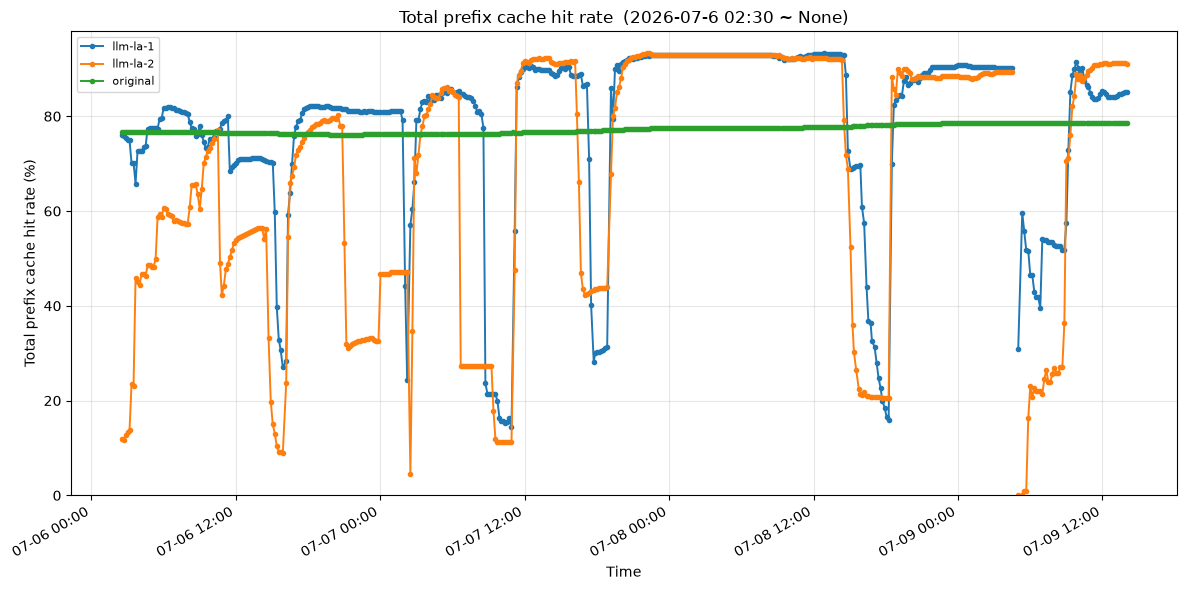

In [24]:
# ============================================================
# Cell 3 — Total prefix cache hit rate line chart over a time window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound
LABELS = ["llm-la-1", "llm-la-2", "original"]   # display labels, in MODELS order
start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)
plt.figure(figsize=(12, 6))
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=disp if c is None else None)
        c = line.get_color()
    print(f"[ok] {m} -> {disp}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("Total prefix cache hit rate (%)")
plt.title(f"Total prefix cache hit rate  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.ylim(bottom=0)
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean cache hit = 78.2%  (n=494)
[ok] MiniMax-M2.7-llmla2-direct65: mean cache hit = 67.6%  (n=494)
[ok] MiniMax-M2.7-direct142: mean cache hit = 77.2%  (n=502)


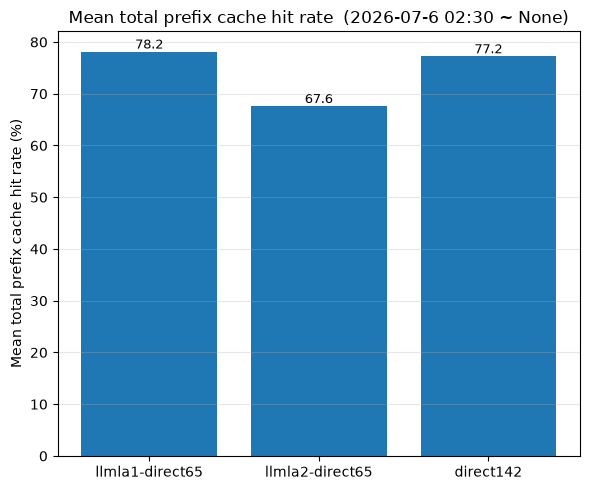

In [25]:
# ============================================================
# Cell 4 — Cache bar chart: mean total prefix cache hit rate per model
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
cache = filter_window(build_cache(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = cache.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean cache hit = {mean:.1f}%  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean total prefix cache hit rate (%)")
plt.title(f"Mean total prefix cache hit rate  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] llm-la avg: 487 points
[ok] Original (142): 502 points
[saved] figures/tps_line_20260706_0230_to_20260709_1405.png


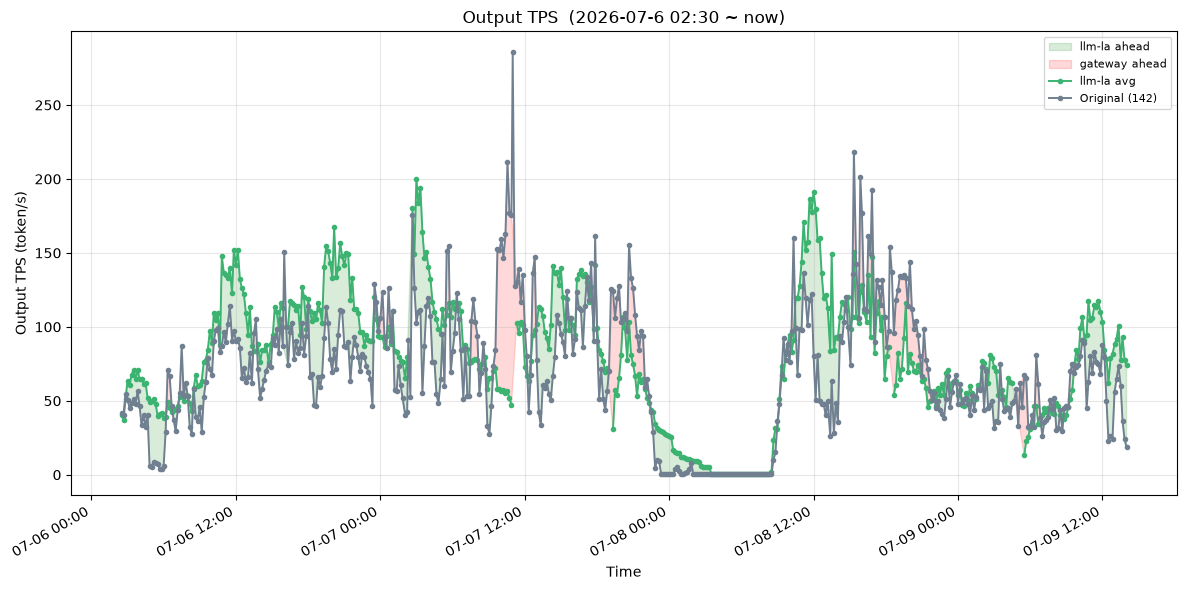

In [26]:
# ============================================================
# Cell 1 — TPS line chart over a time window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None # "2026-06-27 16:15"  # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "Original (142)",
}

import os
import numpy as np
from datetime import datetime

# ── compute per-timestamp mean of the two llm-la series ───
la1 = tps.get("MiniMax-M2.7-llmla1-direct65", {})
la2 = tps.get("MiniMax-M2.7-llmla2-direct65", {})
boom_raw = tps.get("MiniMax-M2.7-direct142", {})

common_ts = sorted(set(la1) & set(la2))
la_mean = {ts: (la1[ts] + la2[ts]) / 2 for ts in common_ts}

# ── align timestamps for fill_between ─────────────────────
all_ts   = sorted(set(la_mean) & set(boom_raw))
xs_align = np.array(all_ts)
la_arr   = np.array([la_mean[ts]   for ts in all_ts])
bm_arr   = np.array([boom_raw[ts]  for ts in all_ts])

PLOT = {
    "llm-la avg":   la_mean,
    "Original (142)": boom_raw,
}
COLORS = {
    "llm-la avg":   "mediumseagreen",
    "Original (142)": "slategray",
}

fig, ax = plt.subplots(figsize=(12, 6))

# ── shaded regions ────────────────────────────────────────
ax.fill_between(xs_align, la_arr, bm_arr,
                where=(la_arr >= bm_arr),
                interpolate=True,
                color="green", alpha=0.15, label="llm-la ahead")
ax.fill_between(xs_align, la_arr, bm_arr,
                where=(la_arr < bm_arr),
                interpolate=True,
                color="red", alpha=0.15, label="gateway ahead")

# ── lines ─────────────────────────────────────────────────
for label, pts in PLOT.items():
    if not pts:
        print(f"[warn] {label}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                        color=COLORS.get(label, c),
                        label=label if c is None else None)
        c = line.get_color()
    print(f"[ok] {label}: {len(pts)} points")

ax.set_xlabel("Time"); ax.set_ylabel("Output TPS (token/s)")
ax.set_title(f"Output TPS  ({START} ~ {END or 'now'})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate(); plt.tight_layout()

# ── save ──────────────────────────────────────────────────
def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")

start_str = _fmt(start, START.replace(" ", "_").replace(":", ""))
end_str   = _fmt(end,   datetime.now().strftime("%Y%m%d_%H%M"))

os.makedirs("figures", exist_ok=True)
out_path = f"figures/tps_line_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 487 points, mean=78.4
[ok] MiniMax-M2.7-llmla2-direct65: 487 points, mean=80.1
[ok] MiniMax-M2.7-direct142: 502 points, mean=70.0
[saved] figures/tps_bar_20260706_0230_to_20260709_1406.png

── TPS summary ──
  llm-la-1          78.4 tok/s  (+12.1% vs boom gateway)
  llm-la-2          80.1 tok/s  (+14.5% vs boom gateway)
  original (142)    70.0 tok/s
  avg               79.3 tok/s  (+13.3% vs boom gateway)


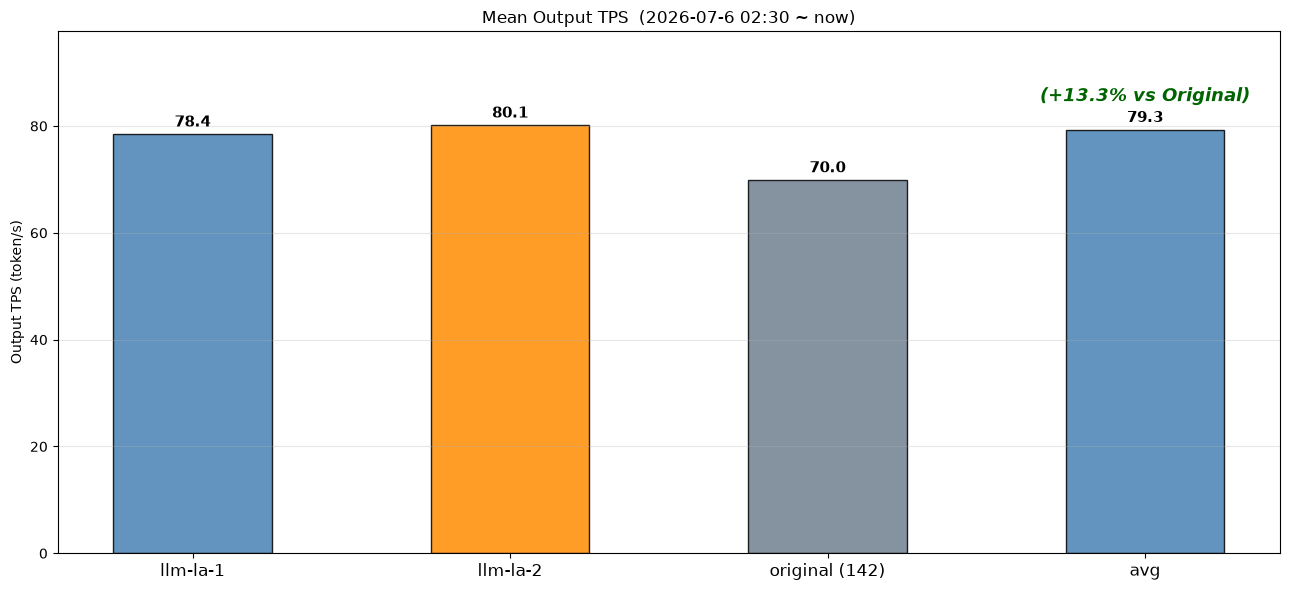

In [27]:
# ============================================================
# Cell 1 — TPS bar chart over a time window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None # "2026-06-27 16:15"  # set to None for no upper bound
start, end = parse_window(START), parse_window(END)
tps = filter_window(build_tps(MODELS), start, end)

DISPLAY = {
    "MiniMax-M2.7-llmla1-direct65": "llm-la-1",
    "MiniMax-M2.7-llmla2-direct65": "llm-la-2",
    "MiniMax-M2.7-direct142":       "original (142)",
}

import numpy as np
from datetime import datetime
import os

# ── collect means ──────────────────────────────────────────
raw_means = {}
for m, label in DISPLAY.items():
    pts = tps.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data in window")
        continue
    vals = list(pts.values())
    raw_means[label] = np.mean(vals)
    print(f"[ok] {m}: {len(vals)} points, mean={raw_means[label]:.1f}")

# ── inject average column ─────────────────────────────────
llmla_vals = [raw_means[k] for k in ("llm-la-1", "llm-la-2") if k in raw_means]
if len(llmla_vals) == 2:
    raw_means["avg"] = np.mean(llmla_vals)

# ── compute % improvement over boom gateway ────────────────
boom = raw_means.get("original (142)")
pct_improvement = {}
if boom and boom > 0:
    for label in ("llm-la-1", "llm-la-2", "avg"):
        if label in raw_means:
            pct_improvement[label] = (raw_means[label] - boom) / boom * 100

# ── plot ───────────────────────────────────────────────────
COLORS = {
    "llm-la-1":    "steelblue",
    "llm-la-2":    "darkorange",
    "llm avg":         "mediumseagreen",
    "original (142)": "slategray",
}

labels = list(raw_means.keys())
means  = list(raw_means.values())
colors = [COLORS.get(l, "steelblue") for l in labels]

fig, ax = plt.subplots(figsize=(13, 6))
x    = np.arange(len(labels))
bars = ax.bar(x, means, width=0.5,
              color=colors, alpha=0.85, edgecolor="black")

for bar, label, mean in zip(bars, labels, means):
    cx = bar.get_x() + bar.get_width() / 2
    ax.text(cx, bar.get_height() * 1.01,
            f"{mean:.1f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
    if label == "avg" and label in pct_improvement:
        pct = pct_improvement[label]
        sign = "+" if pct >= 0 else ""
        ax.text(cx, bar.get_height() * 1.01 + ax.get_ylim()[1] * 0.045,
                f"({sign}{pct:.1f}% vs Original)",
                ha="center", va="bottom", fontsize=13, fontweight="bold",
                color="darkgreen" if pct >= 0 else "crimson",
                fontstyle="italic")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Output TPS (token/s)")
ax.set_ylim(bottom=0, top=max(means) * 1.22)
ax.set_title(f"Mean Output TPS  ({START} ~ {END or 'now'})")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()

# ── save ──────────────────────────────────────────────────
def _fmt(dt, fallback):
    """Format a datetime (or None) to a compact string for filenames."""
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")

start_str = _fmt(start, START.replace(" ", "_").replace(":", ""))
end_str   = _fmt(end,   datetime.now().strftime("%Y%m%d_%H%M"))

os.makedirs("figures", exist_ok=True)
out_path = f"figures/tps_bar_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

# ── print summary ─────────────────────────────────────────
print(f"\n── TPS summary ──")
for label, mean in raw_means.items():
    pct_str = ""
    if label in pct_improvement:
        pct = pct_improvement[label]
        pct_str = f"  ({'+' if pct>=0 else ''}{pct:.1f}% vs boom gateway)"
    print(f"  {label:<14} {mean:>7.1f} tok/s{pct_str}")

plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 485 points
[ok] MiniMax-M2.7-llmla2-direct65: 454 points
[ok] MiniMax-M2.7-direct142: 503 points


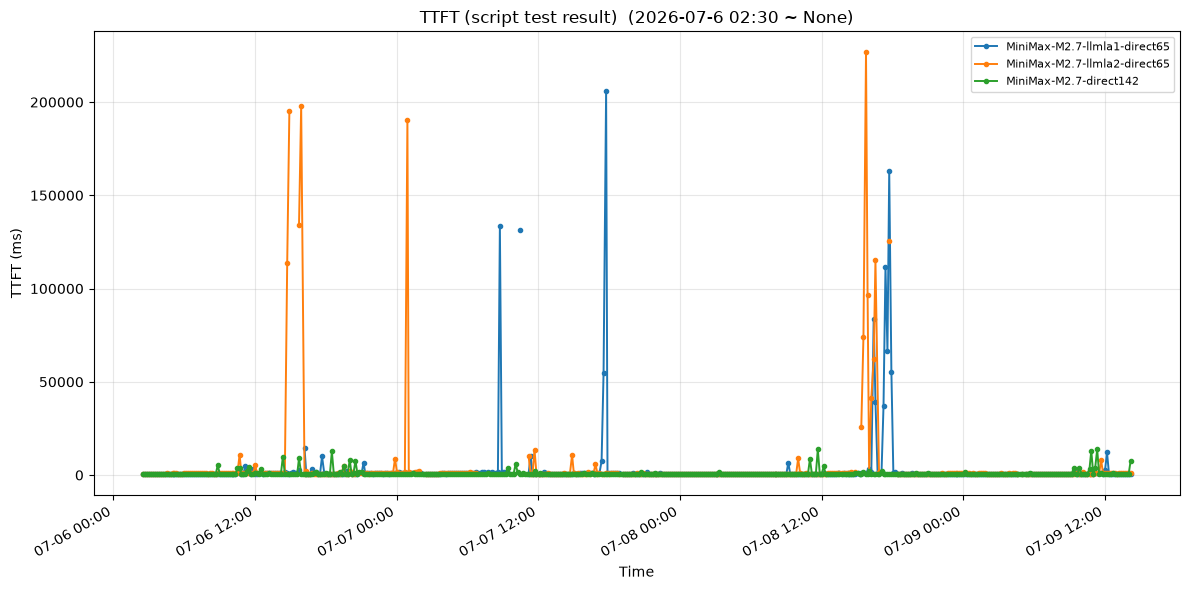

[ok] MiniMax-M2.7-llmla1-direct65: mean TTFT = 3178.2 ms  (n=485)
[ok] MiniMax-M2.7-llmla2-direct65: mean TTFT = 4503.5 ms  (n=454)
[ok] MiniMax-M2.7-direct142: mean TTFT = 891.5 ms  (n=503)


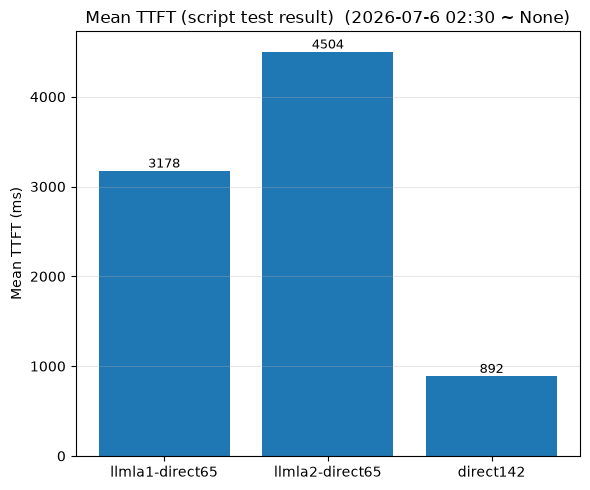

In [28]:
# ============================================================
# Cell 5 — TTFT (script test result) over a time window
# Field: identifier_metrics[model]["ttft"]  (milliseconds)
#
# NOTE: this is the `ttft` field from the data API, which is produced by the
# benchmark script (test_and_collect.py) and surfaced through /api/data.
# It is a DIRECT latency value (ms), NOT a rate -> we take the value as-is,
# no diff/time like TPS.
# CAVEAT: not yet 100% verified to equal the page's "TTFT (script test result)"
# panel free of vLLM-metrics mixing; the field name matches but the DB->API
# mapping was not value-checked. Treat as the data-API ttft field.
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-07-02 17:00"#None  # set to None for no upper bound

def build_ttft(models):
    """Return {model: {datetime: ttft_ms}} taken directly from the ttft field."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            ttft = v.get("ttft") or []
            n = min(len(ttft), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or ttft[i] is None: continue
                series[m][ts_dt[i]] = round(ttft[i], 2)
    return series

start, end = parse_window(START), parse_window(END)
ttft = filter_window(build_ttft(MODELS), start, end)

# ---- line chart ----
plt.figure(figsize=(12, 6))
for m, pts in ttft.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")
plt.xlabel("Time"); plt.ylabel("TTFT (ms)")
plt.title(f"TTFT (script test result)  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

# ---- bar chart: mean TTFT over the window ----
names, means = [], []
for m in MODELS:
    pts = ttft.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean TTFT = {mean:.1f} ms  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.0f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean TTFT (ms)")
plt.title(f"Mean TTFT (script test result)  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: 503 points
[ok] MiniMax-M2.7-llmla2-direct65: 503 points
[ok] MiniMax-M2.7-direct142: 503 points


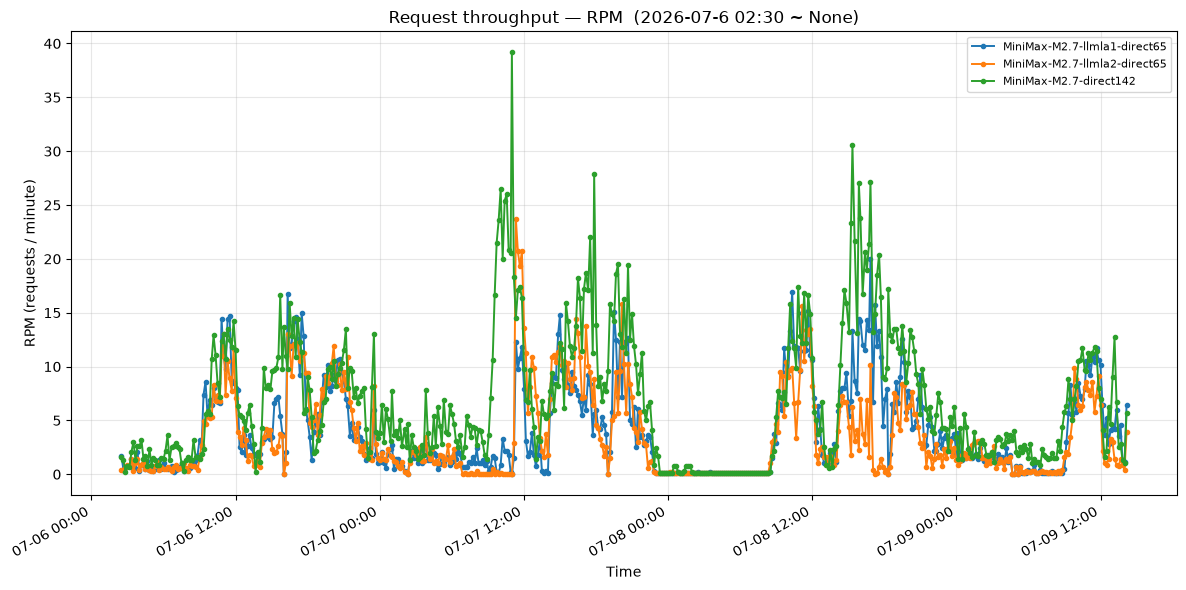

In [29]:
# ============================================================
# Cell A — RPM (requests per minute) line chart over a time window
# RPM = request_increment / actual_minutes_between_adjacent_timestamps (the request_increment is counted by the number of successfully finished requests)
# (uses the real minute span, not a fixed 10, since datapoints are 10~11 min apart)
# ============================================================succew
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

def build_rpm(models):
    """Return {model: {datetime: rpm}} = request_increment / minutes_in_window."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(1, n):                 # need previous ts for the minute span
                if ts_dt[i] is None or ts_dt[i-1] is None: continue
                if incr[i] is None: continue
                minutes = (ts_dt[i] - ts_dt[i-1]).total_seconds() / 60.0
                if minutes <= 0: continue
                series[m][ts_dt[i]] = round(incr[i] / minutes, 2)
    return series

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in rpm.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("RPM (requests / minute)")
plt.title(f"Request throughput — RPM  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean RPM = 4.1  (n=503)
[ok] MiniMax-M2.7-llmla2-direct65: mean RPM = 3.5  (n=503)
[ok] MiniMax-M2.7-direct142: mean RPM = 6.8  (n=503)


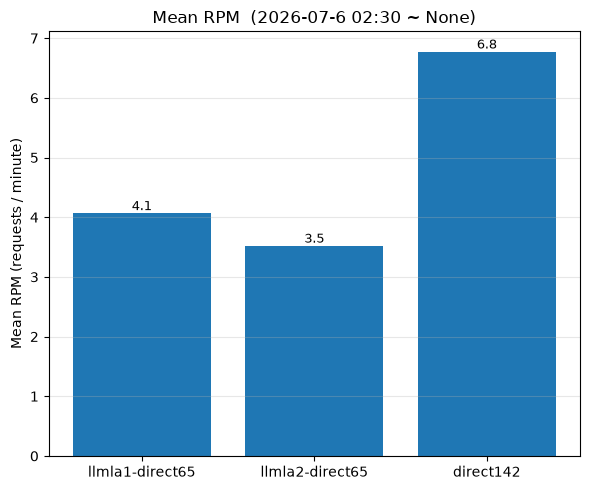

In [30]:
# ============================================================
# Cell B — RPM bar chart: mean RPM per model over the window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
rpm = filter_window(build_rpm(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = rpm.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean RPM = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean RPM (requests / minute)")
plt.title(f"Mean RPM  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()


[ok] MiniMax-M2.7-llmla1-direct65: 503 points
[ok] MiniMax-M2.7-llmla2-direct65: 503 points
[ok] MiniMax-M2.7-direct142: 503 points


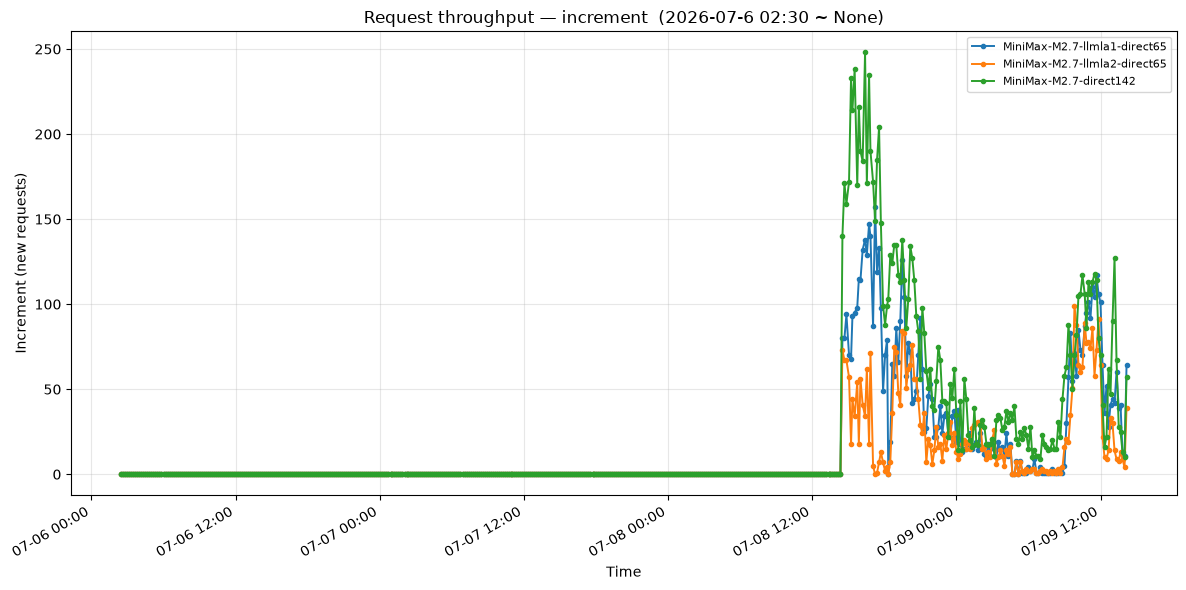

In [31]:
# ============================================================
# Cell C — Increment (new requests per datapoint) line chart over a window
# Source: identifier_metrics[model]["request_increment"] (raw, taken as-is)
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

def build_increment(models):
    """Return {model: {datetime: request_increment}} taken directly."""
    series = {m: {} for m in models}
    for _, d in load_snapshots():
        ts_dt = [parse_ts(x) for x in (d.get("timestamps") or [])]
        idm = d.get("identifier_metrics", {})
        for m in models:
            v = idm.get(m)
            if not v: continue
            incr = v.get("request_increment") or []
            n = min(len(incr), len(ts_dt))
            for i in range(n):
                if ts_dt[i] is None or incr[i] is None: continue
                series[m][ts_dt[i]] = incr[i]
    return series

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

plt.figure(figsize=(12, 6))
for m, pts in inc.items():
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    xs = sorted(pts); ys = [pts[x] for x in xs]
    c = None
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = plt.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                         color=c, label=m if c is None else None)
        c = line.get_color()
    print(f"[ok] {m}: {len(pts)} points")

plt.xlabel("Time"); plt.ylabel("Increment (new requests)")
plt.title(f"Request throughput — increment  ({START} ~ {END})")
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
plt.gcf().autofmt_xdate(); plt.tight_layout()
plt.show()

[ok] MiniMax-M2.7-llmla1-direct65: mean increment = 13.2  (n=503)
[ok] MiniMax-M2.7-llmla2-direct65: mean increment = 7.8  (n=503)
[ok] MiniMax-M2.7-direct142: mean increment = 21.0  (n=503)


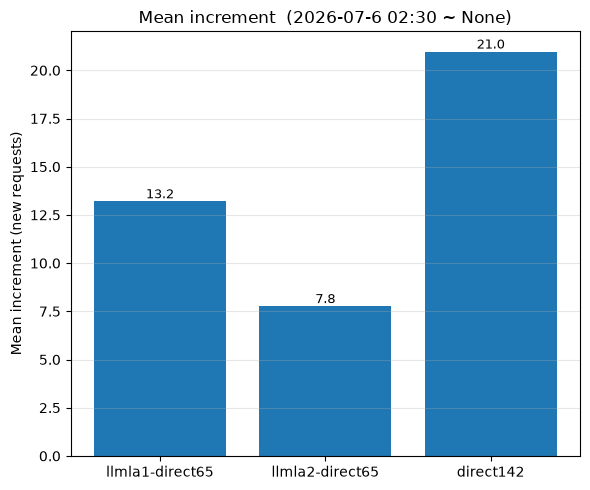

In [32]:
# ============================================================
# Cell D — Increment bar chart: mean increment per model over the window
# ============================================================
START = "2026-07-6 02:30"    # set to None for no lower bound
END   = None #"2026-06-25 21:00"    # set to None for no upper bound

start, end = parse_window(START), parse_window(END)
inc = filter_window(build_increment(MODELS), start, end)

names, means = [], []
for m in MODELS:
    pts = inc.get(m, {})
    if not pts:
        print(f"[warn] {m}: no data"); continue
    mean = sum(pts.values()) / len(pts)
    names.append(m.replace("MiniMax-M2.7-", ""))
    means.append(mean)
    print(f"[ok] {m}: mean increment = {mean:.1f}  (n={len(pts)})")

plt.figure(figsize=(max(6, len(names) * 1.6), 5))
bars = plt.bar(names, means)
for r in bars:
    plt.text(r.get_x() + r.get_width()/2, r.get_height(),
             f"{r.get_height():.1f}", ha="center", va="bottom", fontsize=9)
plt.ylabel("Mean increment (new requests)")
plt.title(f"Mean increment  ({START} ~ {END})")
plt.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plt.show()

[83]

exp 83 time range:
  first: 2026-07-08 20:56:52.581987+00:00
  last:  2026-07-09 06:08:41.093532+00:00
  span:  0 days 09:11:48.511545
  after crop: 0 rows  [NaT ~ NaT]


ValueError: NaTType does not support strftime

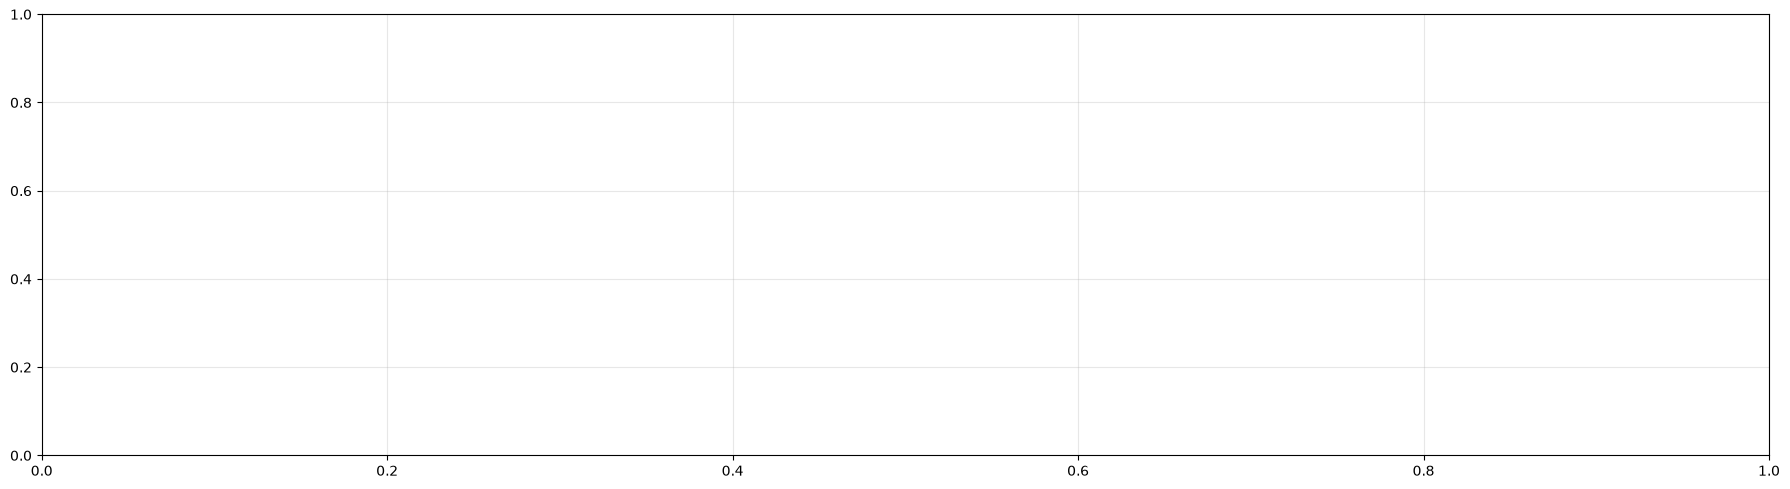

In [33]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os
import numpy as np
from datetime import datetime

# ---- choose experiments ----
experiments = [83]
print(experiments)

# ============================================================
# Choose ONE metric (uncomment exactly one)
# ============================================================
# metric = "sidecar_queue_length"
# metric = "requests_running"
# metric = "requests_waiting"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# --- prefix cache metrics ---
metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
view = "vllm"  # sidecar_* live on vLLM (:8200)

# ── optional time crop (set to None to disable) ───────────
T_START = None
T_END   = "2026-06-27 02:21:08.136732+00:00"

# ── worker groups to average ──────────────────────────────
GROUPS = {
    "llm-la-1": ["server1", "server2"],
    "llm-la-2": ["server3", "server4"],
}
GROUP_COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
}

METRIC_LABELS = {
    "requests_running":             "Requests Running",
    "requests_waiting":             "Requests Waiting",
    "gen_tokens_per_sec":           "Generation Throughput (tok/s)",
    "prefill_tokens_per_sec":       "Prefill Throughput (tok/s)",
    "kv_cache_usage_perc":          "KV Cache Usage (%)",
    "request_success_per_sec":      "Request Success Rate (req/s)",
    "preemptions_per_sec":          "Preemptions (req/s)",
    "ttft_seconds_avg":             "Avg TTFT (s)",
    "tpot_seconds_avg":             "Avg TPOT (s)",
    "e2e_latency_seconds_avg":      "Avg E2E Latency (s)",
    "prefix_cache_hit_rate":        "Prefix Cache Hit Rate",
    "prefix_cache_hits_per_sec":    "Prefix Cache Hits (req/s)",
    "prefix_cache_queries_per_sec": "Prefix Cache Queries (req/s)",
    "sidecar_queue_length":         "Sidecar Queue Length",
}


def _port_of_instance(inst: str):
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]

def _group_mean(df, slots, metric):
    sub = df[df["server_slot"].isin(slots)].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    return (
        sub.groupby("t_rel_s")[metric]
        .mean()
        .sort_index()
    )

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0
crop_start_ts = crop_end_ts = None

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"exp {exp_id}: no data"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    print(f"\nexp {exp_id} time range:")
    print(f"  first: {prom['ts'].min()}")
    print(f"  last:  {prom['ts'].max()}")
    print(f"  span:  {prom['ts'].max() - prom['ts'].min()}")

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]
    print(f"  after crop: {len(prom)} rows  [{prom['ts'].min()} ~ {prom['ts'].max()}]")

    crop_start_ts = prom["ts"].min()
    crop_end_ts   = prom["ts"].max()

    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

metric_label = METRIC_LABELS.get(metric, metric.replace("_", " ").title())

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for group_name, slots in GROUPS.items():
        series = _group_mean(df, slots, metric)
        if series.empty:
            print(f"[warn] {group_name}: no data")
            continue
        ax.plot(
            series.index,
            series.values,
            color=GROUP_COLORS[group_name],
            linewidth=1.5,
            label=group_name,
        )
        print(f"[ok] exp {exp_id} {group_name}: {len(series)} points, mean={series.mean():.2f}")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ── save ──────────────────────────────────────────────────
start_str = _fmt(crop_start_ts, "start")
end_str   = _fmt(crop_end_ts,   datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs("figures", exist_ok=True)
out_path = f"figures/{metric}_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from datetime import datetime

# ---- choose experiments ----
experiments = [83]
print(experiments)

METRICS = {
    "router_admission_rps": "Admission RPS",
}
COLORS = {
    "router_admission_rps": "steelblue",
}

# ── optional time crop (set to None to disable) ───────────
T_START = None
T_END   = None

agg_mode      = "sum"  # "sum" or "mean"
smooth_window = 60     # rolling average window in samples; set to 1 to disable


def _port_of_instance(inst: str):
    try:
        parts = str(inst).split(":")
        if len(parts) >= 2:
            return int(parts[1])
        return None
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

def _fmt(dt, fallback):
    if dt is None:
        return fallback
    return dt.strftime("%Y%m%d_%H%M") if hasattr(dt, "strftime") else str(dt).replace(" ", "_")


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

crop_start_ts = crop_end_ts = None

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"exp {exp_id}: no data"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    print(f"\nexp {exp_id} time range:")
    print(f"  first: {prom['ts'].min()}")
    print(f"  last:  {prom['ts'].max()}")
    print(f"  span:  {prom['ts'].max() - prom['ts'].min()}")

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]

    df = _subset_by_port(prom, 8080)
    if df.empty:
        print(f"exp {exp_id}: no router rows"); continue

    crop_start_ts = df["ts"].min()
    crop_end_ts   = df["ts"].max()

    for metric, label in METRICS.items():
        if metric not in df.columns:
            print(f"[warn] {metric} not found"); continue

        # group by actual timestamp instead of t_rel_s
        if agg_mode == "sum":
            series = df.groupby("ts")[metric].sum(min_count=1)
        else:
            series = df.groupby("ts")[metric].mean()

        series = series.sort_index()
        smoothed = series.rolling(window=smooth_window, center=True, min_periods=1).mean()

        ax.plot(
            smoothed.index,
            smoothed.values,
            color=COLORS[metric],
            linewidth=1.5,
            label=label,
        )
        print(f"[ok] {label}: {len(series)} points, mean={series.mean():.2f}")

ax.set_xlabel("Time")
ax.set_ylabel("Requests per Second")
ax.set_title("Router Admission RPS", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()

# ── save ──────────────────────────────────────────────────
start_str = _fmt(crop_start_ts, "start")
end_str   = _fmt(crop_end_ts,   datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs("figures", exist_ok=True)
out_path = f"figures/router_admission_rps_{start_str}_to_{end_str}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"[saved] {out_path}")

plt.show()

In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- choose experiments ----
experiments = [83]
print(experiments)

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

fig, ax = plt.subplots(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # group by actual timestamp
    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("ts")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    ax.plot(series.index, series.values, label=f"exp{exp_id}")

ax.set_xlabel("Time")
ax.set_ylabel(y_label)
ax.set_title(f"{metric} over time", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ---- choose experiments ----
experiments = [83]
print(experiments)

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "preemptions_per_sec"
# metric = "kv_cache_usage_perc"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"
# --- prefix cache metrics ---
# metric = "prefix_cache_hits_per_sec"
# metric = "prefix_cache_queries_per_sec"
# metric = "prefix_cache_hit_rate"
# metric = "ext_prefix_cache_hits_per_sec"
# metric = "ext_prefix_cache_queries_per_sec"
# metric = "ext_prefix_cache_hit_rate"
# metric = "prompt_tokens_cached_per_sec"
# --- router histogram percentiles ---
# metric = "router_ttft_p50"
# metric = "router_ttft_p95"
# metric = "router_tpot_avg_p50"
# metric = "router_tpot_avg_p95"
# metric = "router_e2e_p50"
# metric = "router_e2e_p95"

# ── time crop ─────────────────────────────────────────────
T_START = "2026-06-26 03:00+00:00"
T_END   = "2026-06-26 09:00+00:00"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

def _parse_ts(s, ref_ts):
    if s is None:
        return None
    ts = pd.Timestamp(s)
    if ref_ts.tzinfo is not None and ts.tzinfo is None:
        ts = ts.tz_localize(ref_ts.tzinfo)
    elif ref_ts.tzinfo is None and ts.tzinfo is not None:
        ts = ts.tz_localize(None)
    return ts

fig, ax = plt.subplots(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    ref = prom["ts"].iloc[0]
    t_start = _parse_ts(T_START, ref)
    t_end   = _parse_ts(T_END,   ref)
    if t_start:
        prom = prom[prom["ts"] >= t_start]
    if t_end:
        prom = prom[prom["ts"] <= t_end]
    print(f"exp {exp_id}: {len(prom)} rows after crop  [{prom['ts'].min()} ~ {prom['ts'].max()}]")

    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("ts")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    ax.plot(series.index, series.values, label=f"exp{exp_id}")

ax.set_xlabel("Time")
ax.set_ylabel(y_label)
ax.set_title(f"{metric}  |  Jun 26  03:00 ~ 09:00 UTC", fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os

# ============================================================
# Combined: prom metric (top) + prefix cache hit rate (bottom)
#   prom timestamps  = UTC  -> converted to China
#   cache timestamps = China wall-clock (Asia/Shanghai)
# ============================================================

# ---- top panel config (prom metric) ----
experiments = [83]
metric = "requests_running"

agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average

# ---- bottom panel config (prefix cache hit rate) ----
START  = "2026-07-6 02:00"
END    = None
LABELS = ["llm-la-1", "llm-la-2", "original"]

# ---- timezone config ----
PROM_TZ  = "UTC"
CACHE_TZ = "Asia/Shanghai"

# ---- vertical marker config ----
# "auto"  -> place line at the requests_running peak (argmax of top series)
# or set an explicit China wall-clock string, e.g. "2026-07-3 14:40"
MARK_TIME = "auto"

# ---- shared color convention ----
COLORS = {
    "llm-la-1": "steelblue",
    "llm-la-2": "darkorange",
    "original": "slategray",
    "boom gateway": "slategray",
}

start, end = parse_window(START), parse_window(END)   # naive China wall-clock

def _prom_index_to_china(idx):
    """Prom index is UTC (aware or naive) -> naive China wall-clock to match cache."""
    idx = pd.DatetimeIndex(idx)
    idx = idx.tz_localize(PROM_TZ) if idx.tz is None else idx.tz_convert(PROM_TZ)
    return idx.tz_convert(CACHE_TZ).tz_localize(None)

# track the real extent of everything plotted (China wall-clock)
data_min = None
data_max = None
def _observe(ts_index):
    global data_min, data_max
    if len(ts_index) == 0:
        return
    lo, hi = pd.Timestamp(min(ts_index)), pd.Timestamp(max(ts_index))
    data_min = lo if data_min is None else min(data_min, lo)
    data_max = hi if data_max is None else max(data_max, hi)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 10), sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# ---------------- TOP: prom metric ----------------
if agg_mode == "sum":
    y_label_top = f"{metric} (sum over instances)"
else:
    y_label_top = f"{metric} (mean over instances)"

peak_time = None   # China wall-clock timestamp of the top-series max

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples"); continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found"); continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    if agg_mode == "sum":
        series = prom.groupby("ts")[metric].sum(min_count=1)
    else:
        series = prom.groupby("ts")[metric].mean()

    # UTC -> China wall-clock, then clip to the same window as the cache panel
    series.index = _prom_index_to_china(series.index)
    idx = series.index
    mask = pd.Series(True, index=idx)
    if start is not None:
        mask &= idx >= start
    if end is not None:
        mask &= idx <= end
    series = series[mask.values]
    if series.empty:
        print(f"[warn] exp{exp_id}: no {metric} points in window"); continue

    ax_top.plot(series.index, series.values, label=f"exp{exp_id}", color="steelblue")
    _observe(series.index)

    # record peak time (from the first/primary experiment)
    if peak_time is None:
        peak_time = series.idxmax()
        print(f"[peak] exp{exp_id}: {metric} max = {series.max():.3g} at {peak_time}")

ax_top.set_ylabel(y_label_top)
ax_top.set_title(f"{metric} over time", fontsize=13, fontweight="bold")
ax_top.legend(loc="upper right")
ax_top.grid(True, alpha=0.3)

# ---------------- BOTTOM: prefix cache hit rate ----------------
cache = filter_window(build_cache(MODELS), start, end)
for i, (m, pts) in enumerate(cache.items()):
    if not pts:
        print(f"[warn] {m}: no data in window"); continue
    disp = LABELS[i] if i < len(LABELS) else m
    col = COLORS.get(disp)
    xs = sorted(pts); ys = [pts[x] for x in xs]
    _observe(xs)
    c = col
    first = True
    for sx, sy in split_gaps(xs, ys, GAP_SECONDS):
        line, = ax_bot.plot(sx, sy, marker="o", markersize=3, linewidth=1.4,
                            color=c, label=disp if first else None)
        c = line.get_color()
        first = False
    print(f"[ok] {m} -> {disp}: {len(pts)} points")

ax_bot.set_ylabel("Total prefix cache hit rate (%)")
ax_bot.set_xlabel("Time")
ax_bot.legend(fontsize=8, loc="upper right")
ax_bot.grid(True, alpha=0.3)
ax_bot.set_ylim(bottom=0)

# ---------------- vertical red marker ----------------
if MARK_TIME == "auto":
    mark = peak_time
else:
    mark = pd.Timestamp(MARK_TIME)   # explicit China wall-clock

if mark is not None:
    for ax in (ax_top, ax_bot):
        ax.axvline(mark, color="red", linestyle="--", linewidth=1.6, alpha=0.9, zorder=5)
    ax_top.annotate(f" {mark:%m-%d %H:%M}",
                    xy=(mark, ax_top.get_ylim()[1]),
                    xytext=(4, -12), textcoords="offset points",
                    color="red", fontsize=9, fontweight="bold",
                    va="top", ha="left")
    print(f"[mark] vertical line at {mark}")
else:
    print("[mark] no marker (peak_time unresolved and MARK_TIME='auto')")

# ---------------- title with real times (fall back to data extent) ----------------
title_lo = start if start is not None else data_min
title_hi = end   if end   is not None else data_max

def _fmt(ts):
    return pd.Timestamp(ts).strftime("%Y-%m-%d %H:%M") if ts is not None else "?"

# ---------------- shared x formatting ----------------
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.suptitle(f"requests_running + prefix cache hit rate  ({_fmt(title_lo)} ~ {_fmt(title_hi)})",
             fontsize=13, fontweight="bold", y=0.995)
fig.autofmt_xdate()
plt.tight_layout()

# ---------------- save ----------------
os.makedirs("figures", exist_ok=True)

def _stamp(ts, fallback):
    return pd.Timestamp(ts).strftime("%Y%m%d-%H%M") if ts is not None else fallback

fname = (f"figures/requests_running_prefix_cache_hit_rate_"
         f"{_stamp(title_lo, 'begin')}_{_stamp(title_hi, 'end')}.png")

fig.savefig(fname, dpi=150, bbox_inches="tight")
print(f"[saved] {fname}")

plt.show()

In [ ]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [83]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
